**SpongeWorks**
-----
Produce a code based taht can source and process EO and other data to be used for : 
* detecting flooded areas over time 
* assessing the role of anti-flooding measures on flood effects intenstity 


# Import packages and functions 

In [9]:
import contextily as ctx
import os
import sys
from datetime import datetime
from glob import glob
import urllib
from pathlib import Path
import cdsapi
import geopandas as gpd
import hvplot.xarray
import imageio
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import openeo
import hvplot.pandas
import pandas as pd
import xarray as xr
from openeo.api.process import Parameter
from shapely.geometry import Point, box
from pyproj import Transformer
import rioxarray 
from datetime import datetime
from pystac_client import Client
import bokeh
from tqdm.notebook import tqdm

In [7]:
# site_name = 'lake_karla'
# basin = gpd.read_file('/Users/vm/Downloads/sites/s7_lake_karla/s7_lake_karla.shp')
# basin_metric = basin.to_crs(basin.estimate_utm_crs())
# minx, miny, maxx, maxy = basin_metric.total_bounds
# bbox_metric = box(minx, miny, maxx, maxy)
# bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_metric], crs=basin_metric.crs).to_crs(basin.crs)
# bbox = bbox_gdf.geometry.iloc[0]
# basin.plot()

# ## Period of interest
# poi = ['2020-01-01', '2025-12-31']
# startYear = int(poi[0][:4])
# endYear = int(poi[1][:4])


# Area & period of interest

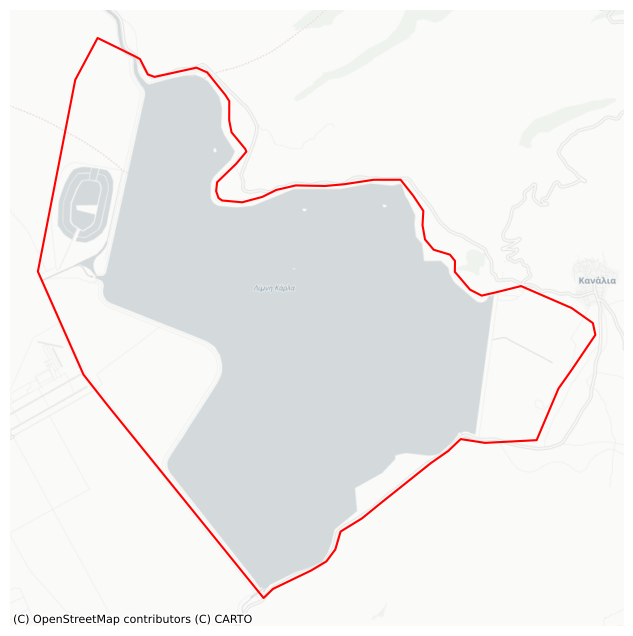

In [8]:
# site_name = 'leze'
site_name = 'pinios'

## Period of interest
poi = ['2015-01-01', '2025-12-31']
startYear = int(poi[0][:4])
endYear = int(poi[1][:4])

if site_name == 'pinios':
    aois = gpd.read_file('/home/vm/Desktop/Pinios/sites/s7_lake_karla/s7_lake_karla.shp')
if site_name == 'leze':    
    # aoi1 = gpd.read_file('/home/vm/Desktop/spongeworks/data/Leze/hedges_aos.gpkg')
    # aoi2 = gpd.read_file('/home/vm/Desktop/spongeworks/data/Leze/eval_sites_aos.gpkg')
    # aois = gpd.GeoDataFrame(pd.concat([aoi1, aoi2], ignore_index=True), crs=aoi1.crs)
    aois = gpd.read_file('/home/vm/Desktop/spongeworks/data/Leze/eval_sites_aos.gpkg')

aois_web = aois.to_crs(epsg=3857)
ax = aois_web.plot(figsize=(8, 8), facecolor="none", edgecolor="red", linewidth=1.5)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_axis_off()
plt.show()

# Build bbox from AOIs extent with +2 km margin on each side
aois_metric = aois.to_crs(aois.estimate_utm_crs())
minx, miny, maxx, maxy = aois_metric.total_bounds

bbox_radius = 100  # 100 meters margin

bbox_metric = box(minx - bbox_radius, miny - bbox_radius, maxx + bbox_radius, maxy + bbox_radius)
bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_metric], crs=aois_metric.crs).to_crs("4326")
bbox = bbox_gdf.geometry.iloc[0]

# fig, ax = plt.subplots(figsize=(10, 10))

# aois.plot(ax=ax, facecolor="orange", edgecolor="darkred", alpha=0.5, label="AOIs")
# bbox_gdf.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=2, linestyle="--", label="Bounding Box")

# ax.set_title("AOI(s) and Bounding Box")
# ax.set_xlabel("Longitude")
# ax.set_ylabel("Latitude")
# # ax.set_xlim(lon_min - 0.1, lon_max + 0.1)
# # ax.set_ylim(lat_min - 0.1, lat_max + 0.1)
# ax.legend()
# ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()


# EO data: source & process

In [2]:
# ## Connect to the openEO back-end and authenticate
# connection = openeo.connect("openeofed.dataspace.copernicus.eu")
# connection.authenticate_oidc()
# # List collections available on the openEO back-end
# # connection.list_collection_ids()
# # Get detailed metadata of a certain collection
# # connection.describe_collection("SENTINEL2_L2A")

# ## Set geographical limits of the bounding box
# W = bbox_gdf.total_bounds[0]
# S = bbox_gdf.total_bounds[1]
# E = bbox_gdf.total_bounds[2]
# N = bbox_gdf.total_bounds[3]

# Sentinel-2 : NDWI

In [3]:
# # Run NDWI extraction year-by-year within the POI window
# output_dir = f"/home/vm/Desktop/spongeworks/eo_data/{site_name}/ndwi/"
# os.makedirs(output_dir, exist_ok=True)

# all_tif_files = []

# for year in range(startYear, endYear + 1):
#     year_start = max(f"{year}-01-01", poi[0])
#     year_end = min(f"{year}-12-31", poi[1])
#     if year_start > year_end:
#         continue

#     year_dir = os.path.join(output_dir, str(year))
#     os.makedirs(year_dir, exist_ok=True)

#     # Skip processing if this year already has outputs
#     year_tifs = sorted(glob(os.path.join(year_dir, "*.tif")))
#     if not year_tifs:
#         try:
#             datacube = connection.load_collection(
#             "SENTINEL2_L2A",
#             spatial_extent={"west": W, "south": S, "east": E, "north": N},
#             temporal_extent=[year_start, year_end],
#             bands=["B03", "B08", "SCL"],
#             max_cloud_cover=50
#             )

#             B03 = datacube.band("B03") * 0.0001
#             B08 = datacube.band("B08") * 0.0001
#             SCL = datacube.band("SCL")

#             # Cloud + shadow mask (SCL classes: 3 shadow, 8/9 cloud)
#             cloud_mask = ((SCL == 8) | (SCL == 9) | (SCL == 3)) * 1.0
#             masked_cube = datacube.mask(cloud_mask)

#             B03_masked = masked_cube.band("B03") * 0.0001
#             B08_masked = masked_cube.band("B08") * 0.0001
#             ndwi_cube = (B03_masked - B08_masked) / (B03_masked + B08_masked)

#             job = ndwi_cube.create_job(title=f"S2_NDWI_{site_name}_{year}")
#             job.start_and_wait()
#             job.get_results().download_files(year_dir)

#             year_tifs = sorted(glob(os.path.join(year_dir, "*.tif")))
#         except Exception as e:
#             print(f"Error processing year {year}: {e}")
#             continue

#     all_tif_files.extend(year_tifs)

# # Keep a single tif_files list for downstream code, filtered to POI
# poi_start = pd.to_datetime(poi[0])
# poi_end = pd.to_datetime(poi[1])

# tif_files = []
# # Build source list even if yearly extraction cell was not executed
# if "all_tif_files" in globals() and len(all_tif_files) > 0:
#     source_tifs = sorted(all_tif_files)
# else:
#     output_dir = f"/home/vm/Desktop/spongeworks/eo_data/{site_name}/ndwi/"
#     source_tifs = sorted(glob(os.path.join(output_dir, "**", "*.tif"), recursive=True))

# for fp in source_tifs:
#     d = pd.to_datetime(os.path.basename(fp)[7:17], format="%Y-%m-%d", errors="coerce")
#     if pd.notna(d) and (poi_start <= d <= poi_end):
#         tif_files.append(fp)

# if not tif_files : raise FileNotFoundError("No .tif files found in the target folder.")

# # Read each tif as DataArray, drop singleton band dimension if present
# ndwi_list = [rioxarray.open_rasterio(fp).squeeze(drop=True) for fp in tif_files]

# date_strs = []
# for fp in tif_files : date_strs.append(fp.split("/")[-1][7:17])

# time_values = pd.to_datetime(date_strs, format="%Y-%m-%d", errors="coerce")

# # Concatenate along time
# ndwi_ds = xr.concat(ndwi_list, dim="time").assign_coords(time=time_values)
# ndwi_ds = ndwi_ds.to_dataset(name="ndwi")

# # Baseline mean over 2017–2025 (per pixel)
# baseline_mean = ndwi_ds["ndwi"].sel(
#     time=slice(f"{startYear}-01-01", f"{endYear}-12-31")
# ).mean(dim="time", skipna=True)

# # Anomaly index where baseline mean = 100
# ndwi_ds["ndwi_anomaly_100"] = ((ndwi_ds["ndwi"] / baseline_mean) - 1) * 100
# ndwi_ds["ndwi_anomaly_100"].attrs.update({
#     "long_name": "NDWI anomaly index (2017-2025 mean = 100)",
#     "units": "index"
# })

# # Convert to Dataset and save
# out_nc = os.path.join(f'/home/vm/Desktop/spongeworks/eo_data/',f"{site_name}_ndwi_{startYear}_{endYear}.nc")
# ndwi_ds.to_netcdf(out_nc)

### Plots - images

In [4]:
# from bokeh.plotting import figure, show, output_notebook
# out_nc = f"/home/vm/Desktop/spongeworks/eo_data/{site_name}//{site_name}_ndwi_{startYear}_{endYear}.nc"
# ndwi_ds_plot = xr.open_dataset(out_nc)
# ndwi_ds_plot["ndwi"].hvplot.image(
#     x="x",
#     y="y",
#     groupby="time",
#     cmap="Blues",
#     clim=(0, 1),
#     rasterize=True,
#     frame_width=750,
#     frame_height=500,
#     title="NDWI over time"
# )

In [10]:
out_nc = f"/home/vm/Desktop/spongeworks/eo_data/{site_name}_ndwi_{startYear}_{endYear}.nc"
ndwi_ds_plot = xr.open_dataset(out_nc)

if ndwi_ds_plot.rio.crs is None:
    ndwi_ds_plot = ndwi_ds_plot.rio.write_crs(aois.estimate_utm_crs())
# Reproject safely (avoid direct EPSG lookup that can fail with PROJ db mismatch)
try:
    target_crs = aois.crs.to_wkt() if aois.crs is not None else None
    if target_crs is not None:
        ndwi_ds_plot = ndwi_ds_plot.rio.reproject(target_crs)
except Exception as e:
    print(f"Skipping NDWI reprojection: {e}")

# Use raw NDWI values instead of anomaly
ndwi_values = ndwi_ds_plot["ndwi"].where(np.isfinite(ndwi_ds_plot["ndwi"]))
ndwi_values = ndwi_values.where(ndwi_values >= 0.0, 0.0)

# Reproject AOIs to NDWI CRS
ndwi_crs = ndwi_ds_plot.rio.crs
aois_reproj_ndwi = aois.to_crs(ndwi_crs) if ndwi_crs is not None else aois.copy()

# Output directory for NDWI images
output_img_dir = f"/home/vm/Desktop/spongeworks/images/ndwi/{site_name}/"
os.makedirs(output_img_dir, exist_ok=True)

# Save one PNG per date
failed_dates = []

for t in ndwi_ds_plot.time.values:
    try:
        date_str = pd.Timestamp(t).strftime("%Y%m%d")
        fig, ax = plt.subplots(figsize=(8, 6))

        ndwi_values.sel(time=t).plot(
            ax=ax,
            cmap="Blues",
            norm=plt.matplotlib.colors.TwoSlopeNorm(vmin=0, vcenter=0.5, vmax=1),
            add_colorbar=True
        )
        aois_reproj_ndwi.boundary.plot(ax=ax, edgecolor="black", linewidth=1, label="AOIs")

        ax.set_title(f"NDWI - {pd.Timestamp(t).strftime('%Y-%m-%d')}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.legend()

        fig.tight_layout()
        fig.savefig(os.path.join(output_img_dir, f"{date_str}.png"), dpi=150)
        plt.close(fig)

    except Exception as e:
        failed_dates.append(str(t))
        plt.close("all")
        print(f"[WARN] Failed NDWI plot for time {t}: {e}")
        continue

if failed_dates:
    print(f"Skipped {len(failed_dates)} date(s).")

print(f"Saved {len(ndwi_ds_plot.time)} NDWI images to '{output_img_dir}/'")

: 

# Sentinel-1 : Backscatter VV/VH

In [ ]:
# # Run Sentinel-1 backscatter extraction year-by-year within the POI window
# output_dir = f'/home/vm/Desktop/spongeworks/eo_data/{site_name}/backscatter/'
# os.makedirs(output_dir, exist_ok=True)

# all_tif_files_bs = []

# for year in range(startYear, endYear + 1):
 
#     if year < 2017:
#         continue
 
#     year_start = max(f"{year}-01-01", poi[0])
#     year_end = min(f"{year}-12-31", poi[1])
 
#     if year_start > year_end:
#         continue

#     year_dir = os.path.join(output_dir, str(year))
#     os.makedirs(year_dir, exist_ok=True)

#     year_tifs = sorted(glob(os.path.join(year_dir, "*.tif")))
#     if not year_tifs:
#         try:
#             datacube = connection.load_collection(
#                 "SENTINEL1_GRD",
#                 spatial_extent={"west": W, "south": S, "east": E, "north": N, "crs": "EPSG:4326"},
#                 temporal_extent=[year_start, year_end],
#                 bands=["VV", "VH"]
#             )

#             s1_scatter = datacube.sar_backscatter(
#                 coefficient="sigma0-ellipsoid",
#                 elevation_model="COPERNICUS_30",
#                 noise_removal=True
#             )
#             s1bs = s1_scatter.apply(lambda x: 10 * x.log(base=10))
#             s1bs = s1bs.resample_spatial(resolution=300, method='med')

#             job = s1bs.create_job(title=f"S1_Backscatter_{site_name}_{year}")
#             job.start_and_wait()
#             job.get_results().download_files(year_dir)

#         except Exception as e:
#             print(f"[WARN] Year {year} failed: {e}")
#             continue

#         year_tifs = sorted(glob(os.path.join(year_dir, "*.tif")))

#     all_tif_files_bs.extend(year_tifs)
#     print(f"Year {year}: {len(year_tifs)} tif files")

# # Filter to POI
# poi_start = pd.to_datetime(poi[0])
# poi_end = pd.to_datetime(poi[1])

# bs_tif_files = []
# for fp in sorted(all_tif_files_bs):
#     d = pd.to_datetime(os.path.basename(fp)[7:17], format="%Y-%m-%d", errors="coerce")
#     if pd.notna(d) and (poi_start <= d <= poi_end):
#         bs_tif_files.append(fp)

# if not bs_tif_files:
#     raise FileNotFoundError("No .tif files found in the target folder.")

# backscatter_list = [rioxarray.open_rasterio(fp).squeeze(drop=True) for fp in bs_tif_files]

# date_strs_bs = [fp.split("/")[-1][7:17] for fp in bs_tif_files]
# time_values_bs = pd.to_datetime(date_strs_bs, format="%Y-%m-%d", errors="coerce")

# backscatter_ds = xr.concat(backscatter_list, dim="time").assign_coords(time=time_values_bs)
# backscatter_ds = backscatter_ds.to_dataset(name="backscatter")

# out_nc = f"/home/vm/Desktop/spongeworks/eo_data/{site_name}_backscatter_{startYear}_{endYear}.nc"
# backscatter_ds.to_netcdf(out_nc)
# print(f"Saved backscatter dataset to '{out_nc}'")

### Plots - images

In [ ]:
out_nc = f"/home/vm/Desktop/spongeworks/eo_data/{site_name}_backscatter_{startYear}_{endYear}.nc"
backscatter_ds_plot = xr.open_dataset(out_nc)

if backscatter_ds_plot.rio.crs is None:
    backscatter_ds_plot = backscatter_ds_plot.rio.write_crs(aois.estimate_utm_crs())

# Use raw backscatter values
backscatter_values = backscatter_ds_plot["backscatter"].where(np.isfinite(backscatter_ds_plot["backscatter"]))

# Select VV and VH bands (assuming band=1: VV, band=2: VH)
backscatter_values_vv = backscatter_values.sel(band=1)
backscatter_values_vh = backscatter_values.sel(band=2)

# Reproject to EPSG:4326 for plotting
backscatter_values_vv = backscatter_values_vv.rio.reproject(backscatter_ds_plot.rio.crs.to_wkt())
backscatter_values_vh = backscatter_values_vh.rio.reproject(backscatter_ds_plot.rio.crs.to_wkt())

# Compute VH/VV ratio (in linear, not dB)
vh_linear = 10 ** (backscatter_values_vh / 10)
vv_linear = 10 ** (backscatter_values_vv / 10)
vh_vv_ratio = vh_linear / vv_linear

# Reproject AOIs
backscatter_crs = backscatter_values_vv.rio.crs
aois_reproj_backscatter = aois.to_crs(backscatter_crs) if backscatter_crs is not None else aois.copy()

output_img_dir = f"/home/vm/Desktop/spongeworks/images/backscatter/{site_name}/"
os.makedirs(output_img_dir, exist_ok=True)

# Thresholds for water detection (adjust as needed)
VH_WATER_THRESH = -23  # dB, area-specific
VH_VV_RATIO_THRESH = np.nanpercentile(vh_vv_ratio.values.flatten(),10) # linear ratio, adjust as needed

for t in backscatter_ds_plot.time.values:
    date_str = pd.Timestamp(t).strftime("%Y%m%d")
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    vv = backscatter_values_vv.sel(time=t)
    vh = backscatter_values_vh.sel(time=t)
    ratio = vh_vv_ratio.sel(time=t)

    # Plot VV
    im0 = vv.plot(ax=axes[0], cmap="gray", vmin=-30, vmax=0, add_colorbar=True, cbar_kwargs={"shrink": 0.8, "label": ""})
    aois_reproj_backscatter.boundary.plot(ax=axes[0], edgecolor="black", linewidth=1)
    axes[0].set_title("VV (dB)")

    # Plot VH/VV
    im1 = ratio.plot(ax=axes[1], cmap="gray",
                     vmin=0, 
                     vmax=np.nanpercentile(vh_vv_ratio.values.flatten(),95)*1.2, add_colorbar=True, cbar_kwargs={"shrink": 0.8, "label": ""})
    aois_reproj_backscatter.boundary.plot(ax=axes[1], edgecolor="black", linewidth=1)
    axes[1].set_title("VH/VV ratio")

    # Water mask: VH < threshold and VH/VV ratio < threshold
    water_mask = (vh < VH_WATER_THRESH) & (ratio < VH_VV_RATIO_THRESH)
    im3 = water_mask.astype(int).plot(
        ax=axes[2],
        cmap=plt.matplotlib.colors.ListedColormap(["white", "blue"]),
        vmin=0, vmax=1,
        add_colorbar=True,
        cbar_kwargs={"shrink": 0.8, "label": "", "ticks": [0, 1]}
    )
    aois_reproj_backscatter.boundary.plot(ax=axes[2], edgecolor="black", linewidth=1)
    axes[2].set_title("Water Mask")

    for ax in axes:
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

    fig.suptitle(f"Backscatter (VV, VH) and resulting Water Mask - {pd.Timestamp(t).strftime('%Y-%m-%d')}")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(os.path.join(output_img_dir, f"{date_str}_vv_vh_ratio_watermask.png"), dpi=150)
    plt.close(fig)


print(f"Saved {len(backscatter_ds_plot.time)} backscatter images to '{output_img_dir}/'")

In [ ]:
# # For each AOI, plot dates where water_mask has at least one pixel=1 within the AOI geometry

# dates_with_water = {}

# for idx, row in aois_reproj_backscatter.iterrows():
#     aoi_name = row["SnB"]
#     aoi_geom = row["geometry"]
#     dates_with_water[aoi_name] = []
#     for i, t in enumerate(backscatter_ds_plot.time.values):
#         # Get water mask for this date
#         wm = ((backscatter_values_vh.sel(time=t) < VH_WATER_THRESH) &
#               (vh_vv_ratio.sel(time=t) < VH_VV_RATIO_THRESH))
#         # Rasterize AOI mask
#         x_coords = wm.x.values
#         y_coords = wm.y.values
#         xx, yy = np.meshgrid(x_coords, y_coords)
#         points = np.vstack((xx.flatten(), yy.flatten())).T
#         mask_flat = np.array([aoi_geom.contains(Point(x, y)) for x, y in points])
#         mask = mask_flat.reshape(wm.shape)
#         # Check if any water pixel inside AOI
#         if np.any(wm.values[mask]):
#             dates_with_water[aoi_name].append(pd.Timestamp(t))

# # Plot for each AOI
# for aoi_name, dates in dates_with_water.items():
#     if dates:
#         plt.figure(figsize=(12, 2))
#         plt.eventplot([pd.to_datetime(dates)], orientation='horizontal', colors='blue')
#         plt.title(f"Dates with detected water in AOI: {aoi_name}")
#         plt.xlabel("Date")
#         plt.yticks([])
#         ax = plt.gca()
#         ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
#         plt.tight_layout()
#         plt.show()
#     else:
#         print(f"No water detected in AOI: {aoi_name}")

In [ ]:
# import pandas as pd

# # Convert the dates_with_water dictionary to a DataFrame

# df_dates_with_water = pd.DataFrame([
#     {"AOI": aoi, "Date": date}
#     for aoi, dates in dates_with_water.items()
#     for date in dates
# ])

# df_dates_with_water.to_csv(f"/Users/vm/Desktop/dir.tmp/spongeworks/dates_with_water_{site_name}.csv", index=False)

<!-- # Global Flood Monitoring

* https://extwiki.eodc.eu/GFM/PDD/GFM_Product_Output_Layers
* https://docs.openeo.cloud/usecases/gfm/#output-layers-used-in-openeo
* https://docs.eodc.eu/tutorials/download_gfm_python.html  -->

In [ ]:
# # EODC STAC API URL
# api_url = "https://stac.eodc.eu/api/v1"
# eodc_catalog = Client.open(api_url)

# # STAC collection ID
# collection_id = "GFM"

# # Time range
# # time_range = (datetime(2022, 9, 15, 0, 0, 0), datetime(2022, 9, 16, 23, 59, 59))
# # time_range = '2022-09-15/2022-09-16'
# time_range = f'{poi[0]}/{poi[1]}'

# # Area of interest from existing bbox limits
# aoi = {
#     "type": "Polygon",
#     "coordinates": [[
#         [float(W), float(S)],
#         [float(W), float(N)],
#         [float(E), float(N)],
#         [float(E), float(S)],
#         [float(W), float(S)],
#     ]],
# }

# search = eodc_catalog.search(
#     # max_items=1000,
#     collections=collection_id,
#     intersects=aoi,
#     datetime=time_range
# )

# items_eodc = search.item_collection()

# # specify output directory
# download_root_path = f"/home/vm/Desktop/spongeworks/eo_data/{site_name}/gfm"

# # specify asset names to download
# asset_names = ["ensemble_flood_extent"]

# for item in items_eodc:
    
#     download_path = os.path.join(download_root_path, item.collection_id, item.id)
#     os.makedirs(download_path, exist_ok=True)
    
#     for asset_name in asset_names:
#         asset = item.assets[asset_name]
#         if "data" in asset.roles:
#             fpath = os.path.join(download_path, os.path.basename(asset.href))
#             print(f"Downlading {fpath}")
#             urllib.request.urlretrieve(asset.href, fpath)


<!-- ### Plots - images -->

In [ ]:
# download_root_path = f"/home/vm/Desktop/spongeworks/eo_data/{site_name}/gfm"
# tif_files = sorted(glob(f"{download_root_path}/GFM/**/*.tif", recursive=True))

# if not tif_files:
#     raise FileNotFoundError("No .tif files found in the target folder.")

# output_img_dir = f"images/gfm_flood_extent/{site_name}/"
# os.makedirs(output_img_dir, exist_ok=True)

# processed = 0
# skipped_files = []
# seen_dates = set()

# for fp in tif_files:
#     fname = os.path.basename(fp)
#     try:
#         stamp = fname.split("_")[2]
#         t = pd.to_datetime(stamp, format="%Y%m%dT%H%M%S", errors="coerce")
#     except Exception:
#         t = pd.NaT

#     date_name = t.strftime("%Y-%m-%d")
#     if date_name in seen_dates:
#         continue
#     seen_dates.add(date_name)

#     out_png = os.path.join(output_img_dir, f"{date_name}.png")
#     if os.path.exists(out_png):
#         continue

#     da = rioxarray.open_rasterio(fp, masked=True).squeeze(drop=True)

#     if da.rio.crs is None:
#         da = da.rio.write_crs(sample_da.rio.crs)

#     try:
#         target_crs = bbox_gdf.crs.to_wkt() if bbox_gdf.crs is not None else None
#         if target_crs is not None and da.rio.crs != bbox_gdf.crs:
#             da = da.rio.reproject(target_crs)
#     except Exception:
#         skipped_files.append(fp)
#         continue
    
#     bbox_reproj_gfm = bbox_gdf.to_crs(da.rio.crs)
#     aois_reproj_gfm = aois.to_crs(da.rio.crs)

#     da = da.where(da != 255).astype("float32")

#     try:
#         da = da.rio.clip(bbox_reproj_gfm.geometry, bbox_reproj_gfm.crs, drop=True)
#     except Exception:
#         skipped_files.append(fp)
#         continue

#     if da.size == 0 or not np.isfinite(da.values).any():
#         skipped_files.append(fp)
#         continue

#     fig, ax = plt.subplots(figsize=(8, 6))
#     da.plot(ax=ax, cmap="Blues", vmin=0, vmax=1, add_colorbar=True)
#     bbox_reproj_gfm.boundary.plot(ax=ax, edgecolor="black", linewidth=1.5)
#     aois_reproj_gfm.boundary.plot(ax=ax, edgecolor="red", linewidth=1)

#     ax.set_title(f"GFM Flood Extent - {date_name}")
#     ax.set_xlabel("x")
#     ax.set_ylabel("y")

#     fig.tight_layout()
#     fig.savefig(out_png, dpi=150)
#     plt.close(fig)

#     processed += 1

# print(f"Saved {processed} images to '{output_img_dir}/'.")
# if skipped_files : 
#     print(f"Skipped {len(skipped_files)} tif files (no basin overlap, all-NaN, bad date, or before 2021).")

# Soil Moisture 

In [ ]:
# # Run SSM extraction year-by-year within the POI window
# output_dir = f"/home/vm/Desktop/spongeworks/eo_data/{site_name}/ssm"
# os.makedirs(output_dir, exist_ok=True)

# all_tif_files_ssm = []

# for year in range(startYear, endYear + 1):
#     year_start = max(f"{year}-01-01", poi[0])
#     year_end = min(f"{year}-12-31", poi[1])
#     if year_start > year_end:
#         continue

#     year_dir = os.path.join(output_dir, str(year))
#     os.makedirs(year_dir, exist_ok=True)

#     # Skip processing if this year already has outputs
#     year_tifs = sorted(glob(os.path.join(year_dir, "*.tif")))
#     if not year_tifs:
#         try:
#             datacube = connection.load_collection(
#                 "CGLS_SSM_V1_EUROPE",
#                 spatial_extent={"west": W, "south": S, "east": E, "north": N},
#                 temporal_extent=[year_start, year_end],
#                 bands=["ssm"]
#             )

#             job = datacube.create_job(title=f"soil_moisture_{site_name}_{year}")
#             job.start_and_wait()
#             job.get_results().download_files(year_dir)

#             year_tifs = sorted(glob(os.path.join(year_dir, "*.tif")))
#         except Exception as e:
#             print(f"[WARN] Year {year} failed: {e}")
#             continue

#     all_tif_files_ssm.extend(year_tifs)
#     print(f"Year {year}: {len(year_tifs)} tif files")

# # Keep only files inside POI dates
# poi_start = pd.to_datetime(poi[0])
# poi_end = pd.to_datetime(poi[1])

# ssm_tif_files = []
# source_tifs = sorted(all_tif_files_ssm) if all_tif_files_ssm else sorted(glob(os.path.join(output_dir, "**", "*.tif"), recursive=True))

# for fp in source_tifs:
#     d = pd.to_datetime(os.path.basename(fp)[7:17], format="%Y-%m-%d", errors="coerce")
#     if pd.notna(d) and (poi_start <= d <= poi_end):
#         ssm_tif_files.append(fp)

# if not ssm_tif_files:
#     raise FileNotFoundError("No SSM .tif files found in the target folder.")

# # Read rasters and build time axis
# ssm_list = [rioxarray.open_rasterio(fp).squeeze(drop=True) for fp in ssm_tif_files]

# date_strs = [os.path.basename(fp)[7:17] for fp in ssm_tif_files]
# time_values = pd.to_datetime(date_strs, format="%Y-%m-%d", errors="coerce")

# if time_values.isna().any():
#     bad = [ssm_tif_files[i] for i, v in enumerate(time_values.isna()) if v][:5]
#     raise ValueError(f"Could not parse dates from some filenames. Examples: {bad}")

# # Concatenate along time and save
# ssm_merged = xr.concat(ssm_list, dim="time").assign_coords(time=time_values)
# ssm_ds = ssm_merged.to_dataset(name="ssm")

# out_nc = f"/home/vm/Desktop/spongeworks/eo_data/{site_name}_ssm_{startYear}_{endYear}.nc"
# ssm_ds.to_netcdf(out_nc, format="NETCDF4")
# print(f"Saved SSM dataset to '{out_nc}'")

### Plots - images

In [ ]:
ssm_ds = xr.open_dataset(f"/home/vm/Desktop/spongeworks/eo_data/{site_name}_ssm_{startYear}_{endYear}.nc")
# ssm_anom = ssm_ds["ssm_anomaly_100"].where(ssm_ds["ssm"] != 255)
ssm = ssm_ds["ssm"].where(ssm_ds["ssm"] != 255)
# if ssm.rio.crs is None:
#     ssm = ssm.rio.write_crs(aois.estimate_utm_crs())
# ssm = ssm.rio.reproject("EPSG:4326")

# Output directory for anomaly images
output_img_dir_anom = f"images/ssm_anomaly/{site_name}/"
os.makedirs(output_img_dir_anom, exist_ok=True)

# Save one PNG per date
for t in ssm_ds.time.values:
    date_str = pd.Timestamp(str(t)).strftime("%Y%m%d")
    fig, ax = plt.subplots(figsize=(8, 6))

    ssm_crs = ssm_ds.rio.crs
    aois_reproj_ssm = aois.to_crs(ssm_crs) if ssm_crs is not None else aois.copy()

    max_abs = float(np.nanmax(np.abs(ssm.values)))
    ssm.sel(time=t).plot(
        ax=ax, cmap="Blues", vmin=0, vmax=300, add_colorbar=True
    )
    aois_reproj_ssm.boundary.plot(ax=ax, edgecolor="black", linewidth=1, label="AOIs")

    ax.set_title(f"Surface Soil Moisture - {pd.Timestamp(str(t)).strftime('%Y-%m-%d')}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()

    fig.tight_layout()
    fig.savefig(os.path.join(output_img_dir_anom, f"{date_str}.png"), dpi=150)
    plt.close(fig)

print(f"Saved {len(ssm_ds.time)} anomaly images to '{output_img_dir_anom}'")

In [ ]:
# # Extract mean SSM anomaly for each AOI
# fig, axes = plt.subplots(len(aois), 1, figsize=(12, 4*len(aois)))
# if len(aois) == 1:
#     axes = [axes]

# # Reproject AOIs to SSM CRS
# aois_reproj_ssm = aois.to_crs(4326) if ssm_anom.rio.crs is None else aois.to_crs(ssm_anom.rio.crs)

# for idx, (ax, aoi_idx) in enumerate(zip(axes, range(len(aois)))):
#     aoi = aois_reproj_ssm.iloc[aoi_idx]
    
#     # Clip SSM anomaly to AOI bounds
#     minx, miny, maxx, maxy = aoi.geometry.bounds
#     ssm_clipped = ssm_anom.sel(x=slice(minx, maxx), y=slice(maxy, miny))
    
#     # Calculate mean over spatial dimensions
#     ssm_mean = ssm_clipped.mean(dim=["x", "y"])
    
#     # Plot time series
#     ax.plot(pd.to_datetime(ssm_mean.time.values), ssm_mean.values, linewidth=2, color="steelblue")
#     ax.set_title(f"Mean SSM Anomaly - AOI {aoi_idx}", fontsize=12)
#     ax.set_xlabel("Time")
#     ax.set_ylabel("SSM Anomaly Index")
#     ax.grid(True, alpha=0.3)
#     ax.xaxis.set_major_locator(mdates.YearLocator())
#     ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
#     ax.tick_params(axis='x', rotation=45)

# plt.tight_layout()
# plt.show()

In [ ]:
# # Load SSM dataset and matching TIFF files
# ssm_ds = xr.open_dataset(f"/Users/vm/Desktop/dir.tmp/spongeworks/eo_data/vecht_ssm_2017_2025.nc")
# ssm_tif_files = sorted(glob(f"/Users/vm/Desktop/dir.tmp/spongeworks/eo_data/vecht_ssm_2017_2025/*.tif"))

# if not ssm_tif_files:
#     raise FileNotFoundError("No SSM .tif files found.")

# # Fix time values from filenames
# ssm_time_values = pd.to_datetime(
#     [fp.split("/")[-1][-15:-5] for fp in ssm_tif_files],
#     format="%Y-%m-%d",
#     errors="coerce"
# )

# if ssm_time_values.isna().any():
#     bad = [ssm_tif_files[i] for i, v in enumerate(ssm_time_values.isna()) if v][:5]
#     raise ValueError(f"Could not parse dates from some SSM filenames. Examples: {bad}")

# # Rebuild dataset with corrected time axis
# ssm_ds_plot = ssm_ds.assign_coords(time=ssm_time_values)

# # Mask nodata
# ssm_masked = ssm_ds_plot["ssm"].where(ssm_ds_plot["ssm"] != 255)

# # Reproject AOIs to SSM CRS
# ssm_crs = rioxarray.open_rasterio(ssm_tif_files[0]).rio.crs
# aois_reproj_ssm = aois.to_crs(ssm_crs) if ssm_crs is not None else aois.copy()

# # Output directory
# output_img_dir = "images/ssm"
# os.makedirs(output_img_dir, exist_ok=True)

# # Save one PNG per date
# for t in ssm_ds_plot.time.values:
#     date_str = pd.Timestamp(t).strftime("%Y%m%d")
#     fig, ax = plt.subplots(figsize=(8, 6))

#     ssm_masked.sel(time=t).plot(
#         ax=ax, cmap="Blues", vmin=0, vmax=200, add_colorbar=True
#     )
#     aois_reproj_ssm.boundary.plot(ax=ax, edgecolor="red", linewidth=1.5, label="AOIs")

#     ax.set_title(f"Soil Moisture (SSM) - {pd.Timestamp(t).strftime('%Y-%m-%d')}")
#     ax.set_xlabel("x")
#     ax.set_ylabel("y")
#     ax.legend()

#     fig.tight_layout()
#     fig.savefig(os.path.join(output_img_dir, f"{date_str}.png"), dpi=150)
#     plt.close(fig)

# print(f"Saved {len(ssm_ds_plot.time)} images to '{output_img_dir}/'")

# Plot 

In [ ]:
# ndwi = xr.open_dataset('/Users/vm/Documents/Scripts and Data/data/spongeworks/ndwi_cube.nc',engine='netcdf4')
# s1 = xr.open_dataset('/Users/vm/Documents/Scripts and Data/data/spongeworks/sar_bs.nc',engine='netcdf4')
# s1['VVVH'] = s1.VV / s1.VH

# # Compute mean values over the spatial dimensions for time series
# ndwi_mean = ndwi["var"].mean(dim=["x", "y"])
# s1_vv_mean = s1["VV"].mean(dim=["x", "y"])
# s1_vh_mean = s1["VH"].mean(dim=["x", "y"])

# # Compute mean VV/VH and interpolate to NDWI time axis
# vvvh_mean = s1["VVVH"].mean(dim=["x", "y"])
# vvvh_interp = vvvh_mean.interp(t=ndwi["var"]["t"])

# # met_DF.index = pd.to_datetime(met_DF['date'])
# # met_DF = met_DF['2018':'2024']
# # Calculate cumulative precipitation that resets each 1 January
# # total_prec_cum = met_DF['prec'].groupby(met_DF.index.year).cumsum()

# # Get all June 1st dates in the time range for vertical lines
# years = np.unique([pd.to_datetime(d).year for d in ndwi_mean["t"].values])
# june_dates = [np.datetime64(f"{y}-06-01") for y in years]

# # Create the figure and axes
# fig, axes = plt.subplots(2, 2, figsize=(12, 8), gridspec_kw={'height_ratios': [1, 1]})

# # Plot time series of mean values
# axes[0, 0].plot(ndwi_mean["t"].values, ndwi_mean.values, label="NDWI", color="green")
# axes[0, 0].set_title("NDWI Mean Time Series")
# axes[0, 0].set_xlabel("Time")
# axes[0, 0].set_ylabel("NDWI")
# axes[0, 0].grid()
# axes[0, 0].xaxis.set_major_locator(mdates.YearLocator())
# axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
# axes[0, 0].tick_params(axis='x', rotation=45)
# for jd in june_dates:
#     axes[0, 0].axvline(jd, color='grey', linestyle='--', alpha=0.7)

# axes[0, 1].plot(ndwi_mean["t"].values, vvvh_interp.values, label="S1 VVVH (VV/VH)", color="orange")
# axes[0, 1].set_title("S1 VVVH (VV/VH) Mean Time Series")
# axes[0, 1].set_xlabel("Time")
# axes[0, 1].set_ylabel("VV/VH")
# axes[0, 1].grid()
# axes[0, 1].xaxis.set_major_locator(mdates.YearLocator())
# axes[0, 1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
# axes[0, 1].tick_params(axis='x', rotation=45)
# for jd in june_dates:
#     axes[0, 1].axvline(jd, color='grey', linestyle='--', alpha=0.7)


# # # Plot cumulative precipitation
# # axes[1, 0].plot(total_prec_cum.index, total_prec_cum.values, color="dodgerblue", label="Cumulative Precipitation")
# # axes[1, 0].set_title("Cumulative Precipitation (reset yearly)")
# # axes[1, 0].set_xlabel("Time")
# # axes[1, 0].set_ylabel("Cumulative Precipitation (m)")
# # axes[1, 0].grid()
# # axes[1, 0].xaxis.set_major_locator(mdates.YearLocator())
# # axes[1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
# # axes[1, 0].tick_params(axis='x', rotation=45)
# # for jd in june_dates:
# #     axes[1, 0].axvline(jd, color='grey', linestyle='--', alpha=0.7)
# # axes[1, 0].legend()

# # # Plot total daily precipitation instead of cumulative
# # axes[1, 1].plot(met_DF.index, met_DF['prec'], color="dodgerblue", label="Daily Precipitation")
# # axes[1, 1].set_title("Total Daily Precipitation")
# # axes[1, 1].set_xlabel("Time")
# # axes[1, 1].set_ylabel("Precipitation (m)")
# # axes[1, 1].grid()
# # axes[1, 1].xaxis.set_major_locator(mdates.YearLocator())
# # axes[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
# # axes[1, 1].tick_params(axis='x', rotation=45)
# # for jd in june_dates:
# #     axes[1, 1].axvline(jd, color='grey', linestyle='--', alpha=0.7)
# # axes[1, 1].legend()

# plt.tight_layout()
# plt.show()


In [ ]:
# ndwi["var"].hvplot(
#     x='x', 
#     y='y', 
#     cmap='Greens', 
#     title='NDWI Map', 
#     clim=(ndwi["var"].min().item(), ndwi["var"].max().item())  # Set color scale limits
# )

In [ ]:
# ndwi["high"] = ndwi['var'].where(ndwi["var"]>=0)
# ndwi["high"].hvplot(
#     x='x', 
#     y='y', 
#     cmap='Greens', 
#     title='NDWI Map', 
# )

In [ ]:
# ndwi = xr.open_dataset('/Users/vm/Documents/Scripts and Data/data/spongeworks/ndwi_cube.nc',engine='netcdf4')
# ndwi = ndwi.rename_vars({'var':'ndwi'})
# s1 = xr.open_dataset('/Users/vm/Documents/Scripts and Data/data/spongeworks/sar_bs.nc',engine='netcdf4')
# s1['VVVH'] = s1.VV / s1.VH

# output_dir = "ndwi_frames"
# os.makedirs(output_dir, exist_ok=True)

# # Read the GeoJSON file containing the stream feature
# points = gpd.read_file('/Users/vm/Documents/Scripts and Data/data/spongeworks/points.geojson')
# # Transform the stream to the desired CRS
# points.geometry = points.geometry.to_crs("EPSG:4326")
# points = points.set_crs(4326,allow_override=True)  # Replace 4326 with the current CRS of the stream data

# stream = gpd.read_file('/Users/vm/Documents/Scripts and Data/data/spongeworks/stream.geojson')
# stream.geometry = stream.geometry.to_crs("EPSG:4326")
# stream = stream.set_crs(4326,allow_override=True)  # Replace 4326 with the current CRS of the stream data

# # Get the global min and max values for the color scale
# vmin = ndwi["ndwi"].min().item()
# vmax = ndwi["ndwi"].max().item()

# # Generate frames for each time step
# time_steps = ndwi["t"]  # Replace "t" with the name of your time dimension
# frame_paths = []

# for i, time in enumerate(time_steps):

#     # Create the plot for the current time step
#     fig, ax = plt.subplots(figsize=(8, 6))
#     im = ndwi["ndwi"].sel(t=time).plot(cmap="vanimo_r", vmin=-1, vmax=1)  # Fix color scale
    
#     # Add the stream feature as an overlay
#     stream.plot(ax=ax, color="blue", linewidth=1, label="Stream")  # Customize color and line width
#     points.plot(ax=ax, color="red", linewidth=1, label="Points")  # Customize color and line width

#     # # Add a colorbar with a shrink factor to scale it proportionally
#     # cbar = fig.colorbar(im, ax=ax, shrink=0.8)  # Adjust shrink to control colorbar size
#     # cbar.set_label("NDWI Value")
    
#     # Add title, labels, and legend
#     ax.set_title(f"NDWI Map - Time: {str(pd.to_datetime(time.values))[:10]}", fontsize=14)
#     ax.set_xlabel("X Coordinate")
#     ax.set_ylabel("Y Coordinate")
#     ax.legend(loc="upper right")  # Add legend for the stream feature
    
#     # Save the plot as a PNG file
#     frame_path = os.path.join(output_dir, f"frame_{i:03d}.png")
#     plt.savefig(frame_path, dpi=150)
#     plt.close()
#     frame_paths.append(frame_path)

# # Create a .gif from the saved frames
# gif_path = "/Users/vm/Desktop/ndwi_animation.gif"
# with imageio.get_writer(gif_path, mode='I', duration=15) as writer:  # Adjust duration for frame speed
#     for frame_path in frame_paths:
#         image = imageio.imread(frame_path)
#         writer.append_data(image)

# print(f"Animation saved as {gif_path}")

# # # Optional: Clean up temporary frame files
# # for frame_path in frame_paths:
# #     os.remove(frame_path)

In [ ]:
# points = points[points.name.isin(['Bund-1','Bund-3'])]
# # Loop through each point and crop ndwi and s1 datasets individually
# cropped_results = []
# buffer_deg  = 0.0001  # Buffer size in degrees
# for idx, row in points.iterrows():
#     # Get point coordinates
#     pt = row.geometry
#     # Buffer around the point (in degrees)
#     minx, miny = pt.x - buffer_deg, pt.y - buffer_deg
#     maxx, maxy = pt.x + buffer_deg, pt.y + buffer_deg

#     # Crop ndwi and s1 datasets to the bounding box for this point
#     ndwi_clip = ndwi.sel(x=slice(minx, maxx), y=slice(maxy, miny))
#     s1_clip = s1.sel(x=slice(minx, maxx), y=slice(maxy, miny))

#     cropped_results.append({
#         "name": row["name"],
#         "ndwi_cropped": ndwi_clip,
#         "s1_cropped": s1_clip
#     })

#     print(f"{row['name']} - ndwi shape: {ndwi_clip['ndwi'].shape}, s1 shape: {s1_clip['VV'].shape}")
#     # Save the clipped NDWI and S1 datasets for each point
#     ndwi_clip.to_netcdf(f"{row['name']}_ndwi_clip.nc")
#     s1_clip.to_netcdf(f"{row['name']}_s1_clip.nc")

In [ ]:
# point_names = ["Bund-1", "Bund-3"]

# for name in point_names:
#     ndwi_cropped = xr.open_dataset(f"/Users/vm/Desktop/dir.tmp/Spongeworks/{name}_ndwi_clip.nc")
#     s1_cropped = xr.open_dataset(f"/Users/vm/Desktop/dir.tmp/Spongeworks/{name}_s1_clip.nc")

#     # Interpolate both NDWI and VV/VH means to a common time axis (NDWI's time)
#     ndwi_cropped_mean = ndwi_cropped["ndwi"].mean(dim=["x", "y"])
#     vvvh_cropped_mean = s1_cropped["VVVH"].mean(dim=["x", "y"])
#     # Interpolate VV/VH to NDWI time
#     vvvh_interp = vvvh_cropped_mean.interp(t=ndwi_cropped["t"])
#     # Interpolate NDWI to NDWI time (identity, but for consistency)
#     ndwi_interp = ndwi_cropped_mean.interp(t=ndwi_cropped["t"])

#     fig, ax1 = plt.subplots(figsize=(10, 5))

#     color1 = "forestgreen"
#     color2 = "royalblue"

#     ax1.set_xlabel("Time")
#     ax1.set_ylabel("NDWI (mean)", color=color1)
#     ax1.plot(
#         ndwi_cropped_mean["t"].values,
#         ndwi_interp.values,
#         color=color1,
#         label="NDWI (mean)",
#         linewidth=2.5,
#     )
#     ax1.tick_params(axis="y", labelcolor=color1)

#     ax2 = ax1.twinx()
#     ax2.set_ylabel("VV/VH (mean, interpolated)", color=color2)
#     ax2.plot(
#         ndwi_cropped_mean["t"].values,
#         vvvh_interp.values,
#         color=color2,
#         label="VV/VH (interp)",
#         linewidth=2.5,
#         linestyle="--",
#     )
#     ax2.tick_params(axis="y", labelcolor=color2)

#     fig.tight_layout()
#     plt.title(f"{name}: NDWI and VV/VH Mean Time Series")
#     plt.show()


In [ ]:
# import seaborn as sns
# from scipy.stats import linregress

# # Interpolate vvvh_cropped_mean to NDWI time for co-temporal points
# vvvh_interp = vvvh_cropped_mean.interp(t=ndwi_cropped_mean["t"])

# # Remove NaNs for scatter/hex plot
# mask = (~np.isnan(ndwi_cropped_mean.values)) & (~np.isnan(vvvh_interp.values))
# x = ndwi_cropped_mean.values[mask]
# y = vvvh_interp.values[mask]

# plt.figure(figsize=(7, 5))
# g = sns.jointplot(x=x, y=y, kind="hex", color="teal", height=6)

# # Overlay actual data points
# g.ax_joint.scatter(x, y, color="red", s=18, alpha=0.7, label="Data points")

# g.ax_joint.legend(loc="upper left")
# g.set_axis_labels("NDWI (mean, cropped)", "VV/VH (mean, cropped, co-temporal)")
# plt.suptitle("Hexbin plot of NDWI vs VV/VH (co-temporal)", y=1.02)
# plt.show()


In [ ]:
# landcover = xr.open_dataset 

## Land Cover 


In [ ]:
# import json
# import joblib
# import requests as r
# from glob import glob
# import time
# import rioxarray
# import gc
# from datetime import datetime, timedelta
# import warnings

# import openeo
# import earthaccess

# WRK_DIR = '/Users/vm/Desktop/dir.tmp/spongeworks/data/'
# IN_DIR = os.path.join(WRK_DIR, 'eo')
# AOI_JSON = '/Users/vm/Desktop/dir.tmp/spongeworks/data/aoi.geojson'
# API_URL = 'https://appeears.earthdatacloud.nasa.gov/api/'
# USER = os.getenv('APPEEARS_USER', 'vmyrg')
# PASSWORD = os.getenv('APPEEARS_PASSWORD', 'CU5-HxX-HyT-AfU')
# TASK_NAME = 'spongeworks_modis'
# OUTPUT_FORMAT = 'netcdf4'
# START_DATE = '01-01-2017'
# END_DATE = '01-01-2025'
    
# if not os.path.exists(IN_DIR):
#     os.makedirs(IN_DIR)
# os.chdir(IN_DIR)

# if os.path.exists(os.path.join(IN_DIR, TASK_NAME)):
#     print(f"Data already exists at {os.path.join(IN_DIR, TASK_NAME)}. Skipping download and processing.")
# else:
#     # ... (Your existing AppEEARS download logic goes here, unchanged) ...
#     # --- Authenticate with AppEEARS API ---
#     token_response = r.post(f'{API_URL}login', auth=(USER, PASSWORD)).json()
#     token = token_response['token']
#     headers = {'Authorization': f'Bearer {token}'}

#     # --- Get available products from AppEEARS ---
#     product_response = r.get(f'{API_URL}product').json()
#     print(f"AρρEEARS currently supports {len(product_response)} products.")
#     products = {p['ProductAndVersion']: p for p in product_response}

#     # --- Helper: Search products by keyword in description ---
#     def print_products_by_keyword(keyword):
#         for p in product_response:
#             if keyword in p['Description']:
#                 pprint.pprint(p)

#     # --- Select layers to download (GPP, LAI, FPAR, Land Cover) ---
#     layers = []
#     # LAI
#     X_product = 'MCD15A2H.061'
#     layers.append({'product': X_product, 'layer': 'Lai_500m'})
#     # FPAR
#     X_product = 'MCD15A2H.061'
#     X_layers = ['Fpar_500m']
#     for layer in X_layers:
#         layers.append({'product': X_product, 'layer': layer})
#     # Land Cover
#     X_product = 'MCD12Q1.061'
#     X_layers = ['LC_Type5','QC']
#     for layer in X_layers:
#         layers.append({'product': X_product, 'layer': layer})

#     # --- Read AOI as GeoJSON and get projection ---
#     nps = gpd.read_file(AOI_JSON)
#     if nps.empty:
#         raise ValueError(f"The AOI file '{AOI_JSON}' is empty or invalid.")
#     nps_json = json.loads(nps.to_json())
#     projections = r.get(f'{API_URL}spatial/proj').json()
#     projs = {p['Name']: p for p in projections}
#     projection_name = projs['geographic']['Name']

#     # --- Build and submit AppEEARS area task ---
#     task = {
#         'task_type': 'area',
#         'task_name': TASK_NAME,
#         'params': {
#             'dates': [{'startDate': START_DATE, 'endDate': END_DATE}], # collect MODIS data 2000-2017 if simulation starts < 2017
#             'layers': layers,
#             'output': {
#                 'format': {'type': OUTPUT_FORMAT},
#                 'projection': projection_name
#             },
#             'geo': nps_json,
#         }
#     }
#     task_response = r.post(f'{API_URL}task', json=task, headers=headers).json()
#     if "task_id" in task_response:
#         task_id = task_response["task_id"]
#         print("Task submitted:", task_id)
#     else:
#         print("Task submission failed:", task_response.get("message", task_response))
#         raise RuntimeError(f"Task submission failed: {task_response.get('message', task_response)}")

#     # --- Wait for AppEEARS task to complete ---
#     def wait_for_task_completion(api_url, task_id, headers):
#         while True:
#             resp = r.get(f'{api_url}task/{task_id}', headers=headers).json()
#             if 'status' in resp:
#                 status = resp['status']
#                 print("Task status:", status)
#                 if status == 'done':
#                     break
#             else:
#                 print("Unexpected response:", resp)
#                 break
#             time.sleep(20)
#     wait_for_task_completion(API_URL, task_id, headers)

#     # --- Download AppEEARS results to local directory ---
#     dest_dir = os.path.join(IN_DIR, TASK_NAME)
#     os.makedirs(dest_dir, exist_ok=True)
#     bundle = r.get(f'{API_URL}bundle/{task_id}', headers=headers).json()
#     files = {f['file_id']: f['file_name'] for f in bundle['files']}
#     for file_id, file_name in files.items():
#         dl = r.get(f'{API_URL}bundle/{task_id}/{file_id}', headers=headers, stream=True)
#         filename = file_name.split('/')[1] if file_name.endswith('.tif') else file_name
#         filepath = os.path.join(dest_dir, filename)
#         with open(filepath, 'wb') as f:
#             for chunk in dl.iter_content(chunk_size=8192):
#                 f.write(chunk)
#     print(f'Downloaded files can be found at: {dest_dir}')

In [ ]:
# LC = xr.open_dataset("/Users/vm/Desktop/dir.tmp/spongeworks/data/eo/spongeworks_modis/MCD12Q1.061_500m_aid0001.nc")
# LC 

In [ ]:
# import matplotlib
# import hvplot.xarray

# # Extract the land cover type variable (assuming 'LC_Type5' is the variable name)
# lc_type = LC['LC_Type5']

# # Get the mapping of class values to names from attributes
# lc_names = lc_type.attrs.get('flag_values', None)
# lc_labels = lc_type.attrs.get('flag_meanings', None)

# if lc_names is not None and lc_labels is not None:
#     if isinstance(lc_names, str):
#         lc_names = [int(x) for x in lc_names.split()]
#     if isinstance(lc_labels, str):
#         lc_labels = lc_labels.split()

#     cmap = matplotlib.cm.get_cmap('tab20', len(lc_names))
#     color_mapping = {v: matplotlib.colors.rgb2hex(cmap(i)) for i, v in enumerate(lc_names)}

#     lc_type.hvplot.image(
#         x='lon', y='lat', z='LC_Type5',
#         cmap=[color_mapping[v] for v in lc_names],
#         colorbar=True,
#         clim=(min(lc_names), max(lc_names)),
#         frame_width=600,
#         frame_height=500,
#         title='Land Cover (LC_Type5)',
#         xlabel='Longitude',
#         ylabel='Latitude'
#     )
# else:
#     lc_type.hvplot.image(
#         x='lon', y='lat', z='LC_Type5',
#         cmap='tab20',
#         colorbar=True,
#         frame_width=600,
#         frame_height=500,
#         title='Land Cover (LC_Type5)',
#         xlabel='Longitude',
#         ylabel='Latitude'
#     )


In [ ]:
# LC.LC_Type5[0,:,:].plot()